# Mengimpor Dataset


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train_jRxnrHD.csv to train_jRxnrHD.csv


In [ ]:
import pandas as pd
df = pd.read_csv('train_jRxnrHD.csv')
df.head()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,sourcing_channel,residence_area_type,premium,target
0,110936,0.429,12058,355060,0.0,0.0,0.0,99.02,13,C,Urban,3300,1
1,41492,0.010,21546,315150,0.0,0.0,0.0,99.89,21,A,Urban,18000,1
2,31300,0.917,17531,84140,2.0,3.0,1.0,98.69,7,C,Rural,3300,0
3,19415,0.049,15341,250510,0.0,0.0,0.0,99.57,9,A,Urban,9600,1
4,99379,0.052,31400,198680,0.0,0.0,0.0,99.87,12,B,Urban,9600,1


# EDA

In [ ]:
df.describe()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,target
count,79853.000000,79853.000000,79853.000000,7.985300e+04,79756.000000,79756.000000,79756.000000,76879.000000,79853.000000,79853.000000,79853.000000
mean,57167.166368,0.314288,18846.696906,2.088472e+05,0.248671,0.078188,0.060008,99.067291,10.863887,10924.507533,0.937397
std,32928.970160,0.334915,5208.719136,4.965826e+05,0.691468,0.436507,0.312023,0.739799,5.170687,9401.676542,0.242248
min,2.000000,0.000000,7670.000000,2.403000e+04,0.000000,0.000000,0.000000,91.900000,2.000000,1200.000000,0.000000
25%,28640.000000,0.034000,14974.000000,1.080100e+05,0.000000,0.000000,0.000000,98.810000,7.000000,5400.000000,1.000000
50%,57262.000000,0.167000,18625.000000,1.665600e+05,0.000000,0.000000,0.000000,99.210000,10.000000,7500.000000,1.000000
75%,85632.000000,0.538000,22636.000000,2.520900e+05,0.000000,0.000000,0.000000,99.540000,14.000000,13800.000000,1.000000
max,114076.000000,1.000000,37602.000000,9.026260e+07,13.000000,17.000000,11.000000,99.890000,60.000000,60000.000000,1.000000


# Data Cleaning

In [ ]:
# One Hot Encoding

df = pd.get_dummies(df, columns=['sourcing_channel', 'residence_area_type'])
df.head()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,target,sourcing_channel_A,sourcing_channel_B,sourcing_channel_C,sourcing_channel_D,sourcing_channel_E,residence_area_type_Rural,residence_area_type_Urban
0,110936,0.429,12058,355060,0.0,0.0,0.0,99.02,13,3300,1,False,False,True,False,False,False,True
1,41492,0.010,21546,315150,0.0,0.0,0.0,99.89,21,18000,1,True,False,False,False,False,False,True
2,31300,0.917,17531,84140,2.0,3.0,1.0,98.69,7,3300,0,False,False,True,False,False,True,False
3,19415,0.049,15341,250510,0.0,0.0,0.0,99.57,9,9600,1,True,False,False,False,False,False,True
4,99379,0.052,31400,198680,0.0,0.0,0.0,99.87,12,9600,1,False,True,False,False,False,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79853 entries, 0 to 79852
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                79853 non-null  int64  
 1   perc_premium_paid_by_cash_credit  79853 non-null  float64
 2   age_in_days                       79853 non-null  int64  
 3   Income                            79853 non-null  int64  
 4   Count_3-6_months_late             79756 non-null  float64
 5   Count_6-12_months_late            79756 non-null  float64
 6   Count_more_than_12_months_late    79756 non-null  float64
 7   application_underwriting_score    76879 non-null  float64
 8   no_of_premiums_paid               79853 non-null  int64  
 9   premium                           79853 non-null  int64  
 10  target                            79853 non-null  int64  
 11  sourcing_channel_A                79853 non-null  bool   
 12  sour

In [ ]:
# Mengubah kolom boolean menjadi integer

cols_to_convert = ['sourcing_channel_A', 'sourcing_channel_B', 'sourcing_channel_C', 'sourcing_channel_D',
                   'sourcing_channel_E','residence_area_type_Rural', 'residence_area_type_Urban']
for col in cols_to_convert:
    df[col] = df[col].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79853 entries, 0 to 79852
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                79853 non-null  int64  
 1   perc_premium_paid_by_cash_credit  79853 non-null  float64
 2   age_in_days                       79853 non-null  int64  
 3   Income                            79853 non-null  int64  
 4   Count_3-6_months_late             79756 non-null  float64
 5   Count_6-12_months_late            79756 non-null  float64
 6   Count_more_than_12_months_late    79756 non-null  float64
 7   application_underwriting_score    76879 non-null  float64
 8   no_of_premiums_paid               79853 non-null  int64  
 9   premium                           79853 non-null  int64  
 10  target                            79853 non-null  int64  
 11  sourcing_channel_A                79853 non-null  int64  
 12  sour

In [ ]:
df.head()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,target,sourcing_channel_A,sourcing_channel_B,sourcing_channel_C,sourcing_channel_D,sourcing_channel_E,residence_area_type_Rural,residence_area_type_Urban
0,110936,0.429,12058,355060,0.0,0.0,0.0,99.02,13,3300,1,0,0,1,0,0,0,1
1,41492,0.010,21546,315150,0.0,0.0,0.0,99.89,21,18000,1,1,0,0,0,0,0,1
2,31300,0.917,17531,84140,2.0,3.0,1.0,98.69,7,3300,0,0,0,1,0,0,1,0
3,19415,0.049,15341,250510,0.0,0.0,0.0,99.57,9,9600,1,1,0,0,0,0,0,1
4,99379,0.052,31400,198680,0.0,0.0,0.0,99.87,12,9600,1,0,1,0,0,0,0,1


In [ ]:
import pandas as pd
missing_count = df.isnull().sum()
print(missing_count)

id                                     0
perc_premium_paid_by_cash_credit       0
age_in_days                            0
Income                                 0
Count_3-6_months_late                 97
Count_6-12_months_late                97
Count_more_than_12_months_late        97
application_underwriting_score      2974
no_of_premiums_paid                    0
premium                                0
target                                 0
sourcing_channel_A                     0
sourcing_channel_B                     0
sourcing_channel_C                     0
sourcing_channel_D                     0
sourcing_channel_E                     0
residence_area_type_Rural              0
residence_area_type_Urban              0
dtype: int64


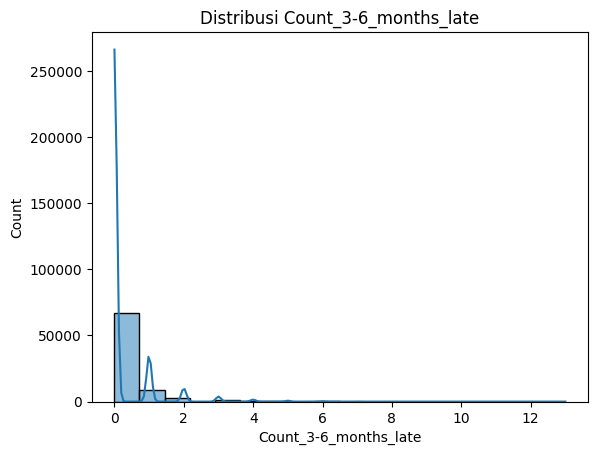

In [ ]:
# Memeriksa distrbusi data tiap kolom
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Count_3-6_months_late'].dropna(), kde=True)
plt.title('Distribusi Count_3-6_months_late')
plt.show()

In [ ]:
# Imputasi median
median_value = df['Count_3-6_months_late'].median()
df['Count_3-6_months_late'].fillna(median_value, inplace=True)

<ipython-input-10-09628fd52fef>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Count_3-6_months_late'].fillna(median_value, inplace=True)


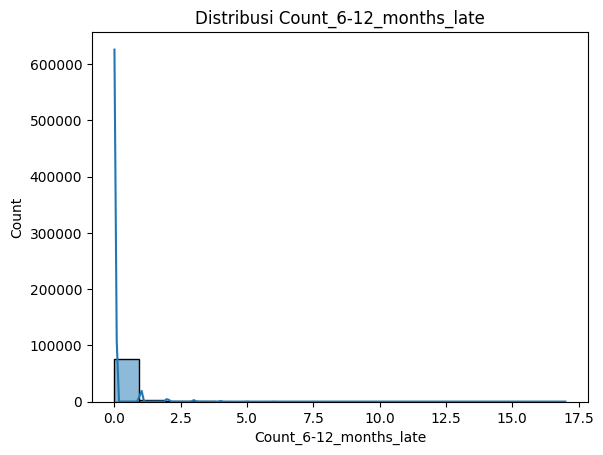

In [ ]:
sns.histplot(df['Count_6-12_months_late'].dropna(), kde=True)
plt.title('Distribusi Count_6-12_months_late')
plt.show()

In [ ]:
# Imputasi median
median_value = df['Count_6-12_months_late'].median()
df['Count_6-12_months_late'].fillna(median_value, inplace=True)


<ipython-input-12-ab9b5138d312>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Count_6-12_months_late'].fillna(median_value, inplace=True)


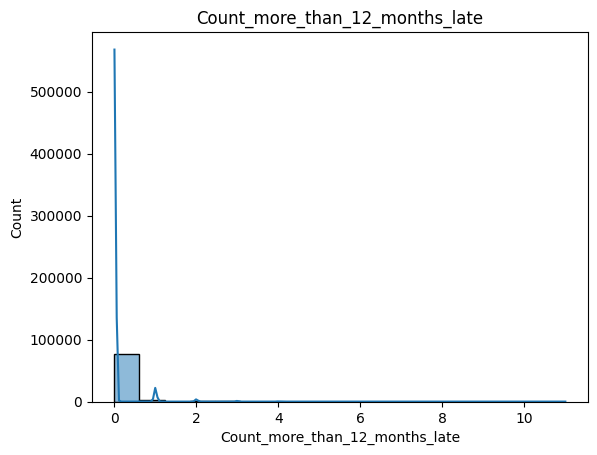

In [ ]:
sns.histplot(df['Count_more_than_12_months_late'].dropna(), kde=True)
plt.title('Count_more_than_12_months_late')
plt.show()

In [ ]:
# Imputasi median
median_value = df['Count_more_than_12_months_late'].median()
df['Count_more_than_12_months_late'].fillna(median_value, inplace=True)


<ipython-input-14-94d283d62973>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Count_more_than_12_months_late'].fillna(median_value, inplace=True)


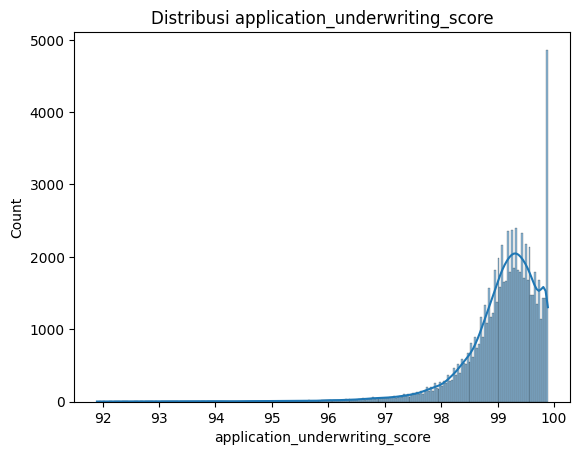

In [ ]:
sns.histplot(df['application_underwriting_score'].dropna(), kde=True)
plt.title('Distribusi application_underwriting_score')
plt.show()

Hasil plot menunjukkan bahwa distribusi tidak simetris dan data condong ke kiri (banyak nilai mendekati 100, ekor di kiri). Ini disebut left-skewed (negatively skewed).

In [ ]:
# Imputasi median

median_value = df['application_underwriting_score'].median()
df['application_underwriting_score'].fillna(median_value, inplace=True)

<ipython-input-16-3f9b63227e9d>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['application_underwriting_score'].fillna(median_value, inplace=True)


In [ ]:
missing_count = df.isnull().sum()
print(missing_count)

id                                  0
perc_premium_paid_by_cash_credit    0
age_in_days                         0
Income                              0
Count_3-6_months_late               0
Count_6-12_months_late              0
Count_more_than_12_months_late      0
application_underwriting_score      0
no_of_premiums_paid                 0
premium                             0
target                              0
sourcing_channel_A                  0
sourcing_channel_B                  0
sourcing_channel_C                  0
sourcing_channel_D                  0
sourcing_channel_E                  0
residence_area_type_Rural           0
residence_area_type_Urban           0
dtype: int64


In [ ]:
df['age_in_days'] = (df['age_in_days'] / 365).astype(int)
df = df.rename(columns={'age_in_days': 'age_in_years'})
df.head()

,id,perc_premium_paid_by_cash_credit,age_in_years,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,premium,target,sourcing_channel_A,sourcing_channel_B,sourcing_channel_C,sourcing_channel_D,sourcing_channel_E,residence_area_type_Rural,residence_area_type_Urban
0,110936,0.429,33,355060,0.0,0.0,0.0,99.02,13,3300,1,0,0,1,0,0,0,1
1,41492,0.010,59,315150,0.0,0.0,0.0,99.89,21,18000,1,1,0,0,0,0,0,1
2,31300,0.917,48,84140,2.0,3.0,1.0,98.69,7,3300,0,0,0,1,0,0,1,0
3,19415,0.049,42,250510,0.0,0.0,0.0,99.57,9,9600,1,1,0,0,0,0,0,1
4,99379,0.052,86,198680,0.0,0.0,0.0,99.87,12,9600,1,0,1,0,0,0,0,1


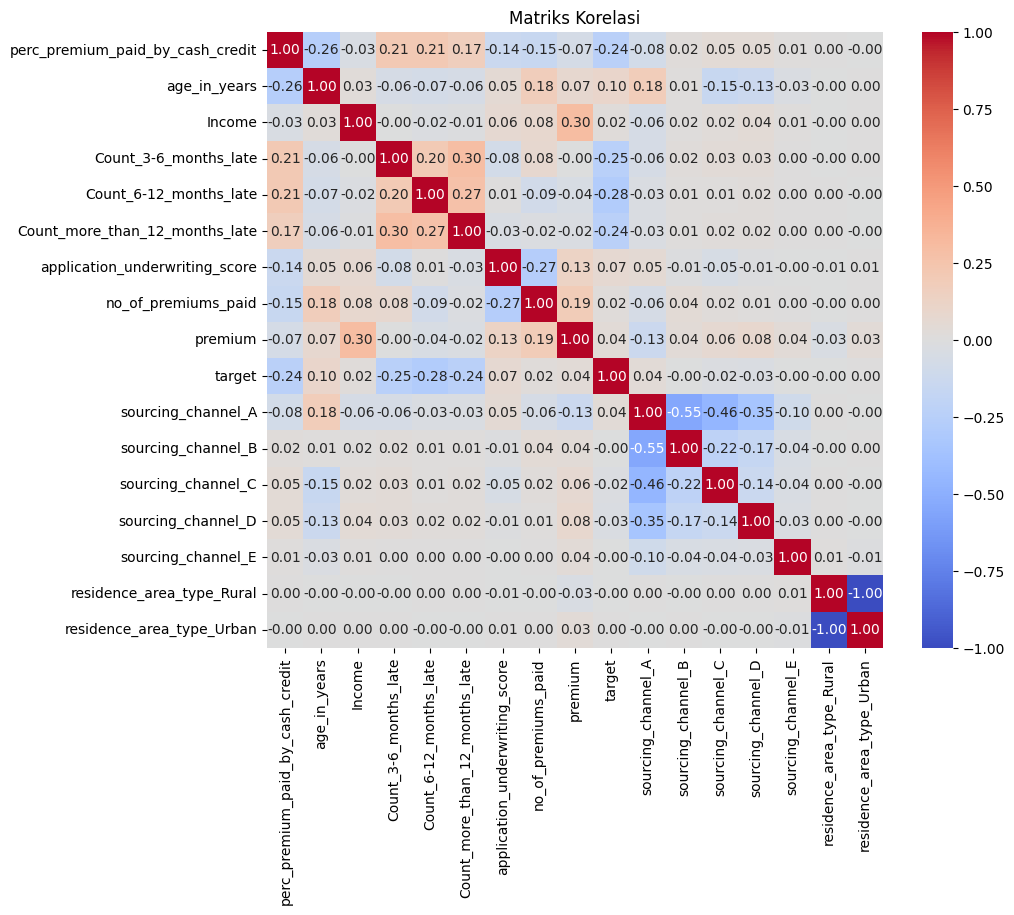

In [ ]:
# Matriks korelasi

# Mengecualikan kolom "id"
df_no_id = df.drop(columns=['id'], errors='ignore')

# Hitung korelasi (default Pearson)
correlation_matrix = df_no_id.corr(numeric_only=True)

# Tampilkan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Matriks Korelasi")
plt.show()

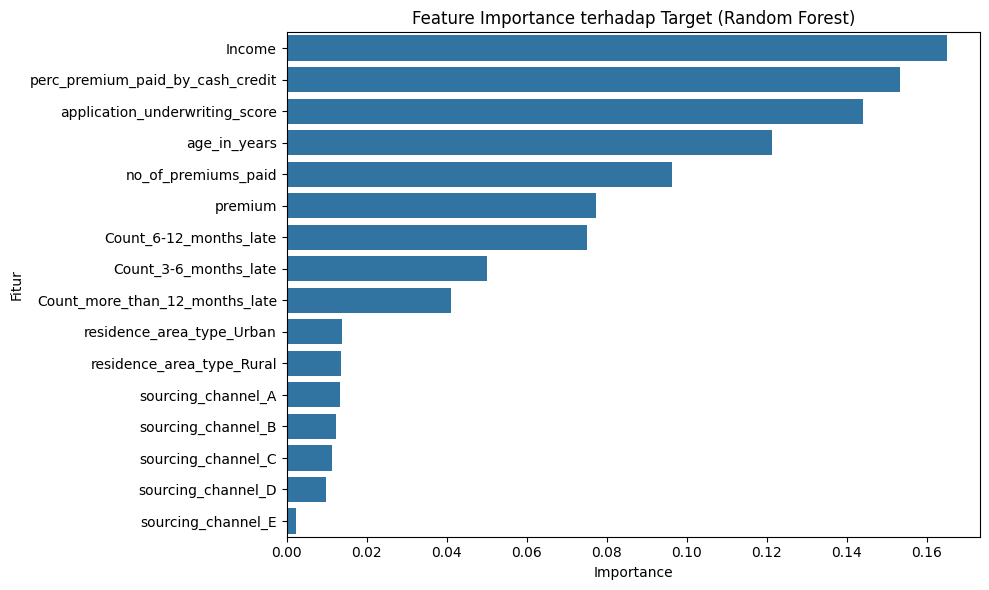

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Salin dataset dan siapkan X dan y
df_clean = df.copy()

# Pisahkan fitur dan target
X = df_clean.drop(columns=['id', 'target'])
y = df_clean['target']

# Latih Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Ambil feature importance
importances = model.feature_importances_
features = pd.Series(importances, index=X.columns)

# Urutkan dan tampilkan
features_sorted = features.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=features_sorted.values, y=features_sorted.index)
plt.title("Feature Importance terhadap Target (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

# Menentukan Alternatif dan Kriteria

Alternatif adalah ID. ID ini nantinya akan diurutkan berdasarkan ranking/peringkat. Peringkat tertinggi adalah pemegang polis terbaik yang dapat dijadikan prioritas/diberikan layanan yang lebih baik. Selain itu, pemeringkatan ini juga dapat digunakan untuk menentukan pemegang polis yang potensial sehingga pihak marketing dapat memaksimalkan strategi pemasaran.

Kriteria yang digunakan adalah:
1. Persentase Premi yang Sudah Dibayarkan
2. Usia
3. Penghasilan
4. Frekuensi pembayaran terlambat selama 3--6 bulan
5. Frekuensi pembayaran terlambat selama 6 bulan--12 bulan
6. Frekuensi pemabayran terlambat lebih dari 12 bulan
7. Skor underwriting
8. Jumlah premi yang Sudah Dibayarkan
9. Nominal premi
10. Sourcing channel
11. Tipe residen
12. Target


In [ ]:
# Kolom kriteria
exclude_columns = ['id']
kriteria_columns = [col for col in df.columns if col not in exclude_columns]

# Kolom 'id' sebagai alternatif
df_ready = df.set_index('id')[kriteria_columns]

# Bentuk akhir data yang siap digunakan untuk TOPSIS
df_ready_shape = df_ready.shape
df_ready_preview = df_ready.head()

df_ready_shape, df_ready_preview

((79853, 17),
         perc_premium_paid_by_cash_credit  age_in_years  Income  \
 id                                                               
 110936                             0.429            33  355060   
 41492                              0.010            59  315150   
 31300                              0.917            48   84140   
 19415                              0.049            42  250510   
 99379                              0.052            86  198680   
 
         Count_3-6_months_late  Count_6-12_months_late  \
 id                                                      
 110936                    0.0                     0.0   
 41492                     0.0                     0.0   
 31300                     2.0                     3.0   
 19415                     0.0                     0.0   
 99379                     0.0                     0.0   
 
         Count_more_than_12_months_late  application_underwriting_score  \
 id                             

# Menentukan Variabel Linguistik

Tahap pertama sebelum masuk ke perhitungan TOPSIS adalah perhitungan fuzzy. Pertama, dilakukan pembobotan dan menetapkan nilai untuk setiap kriteria bilangan fuzzy dan variabel linguistik.

Pada pembobotan ini, digunakan interval untuk membagi tingkatan. Untuk 4 tingkatan: Rendah, Cukup, Tinggi, dan Sangat Tinggi. Untuk 3 tingkatan: Rendah, Sedang, dan Tinggi.

In [ ]:
import pandas as pd

# Pembobotan untuk setiap kriteria
def classify_linguistic(series, level=4):
    μ = series.mean()
    σ = series.std()

    if level == 4:
        bins = [float('-inf'), μ - 1.5 * σ, μ, μ + 1.5 * σ, float('inf')]
        labels = ['Rendah', 'Cukup', 'Tinggi', 'Sangat Tinggi']
    elif level == 3:
        bins = [float('-inf'), μ - σ, μ + σ, float('inf')]
        labels = ['Rendah', 'Cukup', 'Tinggi']
    else:
        raise ValueError("Level harus 3 atau 4")

    return pd.cut(series, bins=bins, labels=labels, include_lowest=True)

# Terapkan pada semua kolom numerik
linguistik_df = df.copy()
for col in linguistik_df.columns:
    linguistik_df[col] = classify_linguistic(linguistik_df[col], level=4)

# Lihat hasil
print(linguistik_df.head())


              id perc_premium_paid_by_cash_credit   age_in_years  Income  \
0  Sangat Tinggi                           Tinggi          Cukup  Tinggi   
1          Cukup                            Cukup         Tinggi  Tinggi   
2          Cukup                    Sangat Tinggi          Cukup   Cukup   
3          Cukup                            Cukup          Cukup  Tinggi   
4         Tinggi                            Cukup  Sangat Tinggi   Cukup   

  Count_3-6_months_late Count_6-12_months_late Count_more_than_12_months_late  \
0                 Cukup                  Cukup                          Cukup   
1                 Cukup                  Cukup                          Cukup   
2         Sangat Tinggi          Sangat Tinggi                  Sangat Tinggi   
3                 Cukup                  Cukup                          Cukup   
4                 Cukup                  Cukup                          Cukup   

  application_underwriting_score no_of_premiums_paid pre

# Defuzzifikasi

In [ ]:
# Mendefinisikan Triangular Fuzzy Numbers (TFN) untuk setiap label
#Ketentuan bilangan fuzzy dan varibel linguistik
fuzzy_scale = {
    'Sangat Rendah': (0.01, 0.01, 0.25),
    'Rendah': (0.01, 0.25, 0.5),
    'Cukup': (0.25, 0.5, 0.75),
    'Tinggi': (0.5, 0.75, 1.0),
    'Sangat Tinggi': (0.75,1.0,1.0),
}

# Defuzzifikasi (ambil rata-rata dari TFN)
def defuzzify(tfn):
    return (tfn[0] + tfn[1] + tfn[2]) / 3

# Ubah semua kategori linguistik menjadi nilai defuzzifikasi
defuzzified_df = linguistik_df.copy()
for col in defuzzified_df.columns:
    defuzzified_df[col] = defuzzified_df[col].map(lambda x: defuzzify(fuzzy_scale[x]))

print(defuzzified_df.head())


         id perc_premium_paid_by_cash_credit age_in_years Income  \
0  0.916667                         0.750000     0.500000   0.75   
1  0.500000                         0.500000     0.750000   0.75   
2  0.500000                         0.916667     0.500000   0.50   
3  0.500000                         0.500000     0.500000   0.75   
4  0.750000                         0.500000     0.916667   0.50   

  Count_3-6_months_late Count_6-12_months_late Count_more_than_12_months_late  \
0              0.500000               0.500000                       0.500000   
1              0.500000               0.500000                       0.500000   
2              0.916667               0.916667                       0.916667   
3              0.500000               0.500000                       0.500000   
4              0.500000               0.500000                       0.500000   

  application_underwriting_score no_of_premiums_paid premium    target  \
0                           0.

In [ ]:
print(defuzzified_df.dtypes)

id                                  category
perc_premium_paid_by_cash_credit    category
age_in_years                        category
Income                              category
Count_3-6_months_late               category
Count_6-12_months_late              category
Count_more_than_12_months_late      category
application_underwriting_score      category
no_of_premiums_paid                 category
premium                             category
target                              category
sourcing_channel_A                  category
sourcing_channel_B                  category
sourcing_channel_C                  category
sourcing_channel_D                  category
sourcing_channel_E                  category
residence_area_type_Rural           category
residence_area_type_Urban           category
dtype: object


In [ ]:
# drop Kolom "id" dan "target" dari defuzzified_df

defuzzified_df = defuzzified_df.drop(columns=['id', 'target'])

In [ ]:
for col in defuzzified_df.select_dtypes(include='category').columns:
    defuzzified_df[col] = defuzzified_df[col].astype(float)

# TOPSIS

Normalisasi Matriks

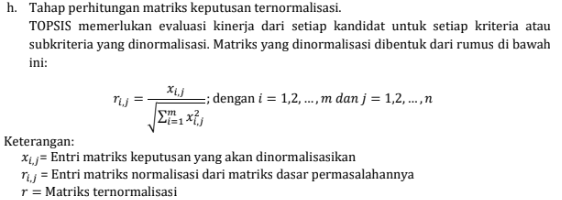

In [ ]:
import numpy as np

# Normalisasi matriks
norm_matrix = defuzzified_df / np.sqrt((defuzzified_df**2).sum())

Matriks Normalisasi Terbobot

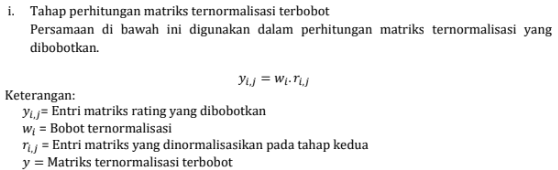

In [ ]:
# Daftar bobot sesuai urutan fitur (dari grafik)
weights_list = [
    0.1860,  # income
    0.1628,  # perc_premium_paid_by_cash_credit
    0.1395,  # application_underwriting_score
    0.1163,  # age_in_years
    0.0930,  # no_of_premiums_paid
    0.0698,  # premium
    0.0581,  # Count_6-12_months_late
    0.0465,  # Count_3-6_months_late
    0.0349,  # Count_more_than_12_months_late
    0.0291,  # residence_area_type_Urban
    0.0233,  # residence_area_type_Rural
    0.0174,  # sourcing_channel_A
    0.0116,  # sourcing_channel_B
    0.0058,  # sourcing_channel_C
    0.0035,  # sourcing_channel_D
    0.0023   # sourcing_channel_E
]

# Konversi ke array numpy
weights = np.array(weights_list)

# Matriks Normalisasi Terbobot
n_criteria = norm_matrix.shape[1]
weighted_matrix = norm_matrix * weights

Matriks Solusi Ideal Positif dan Negatif

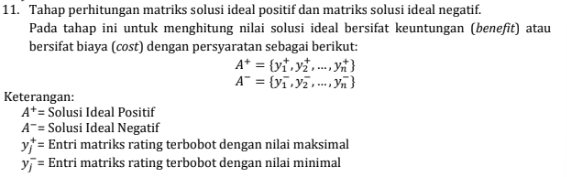

In [ ]:
# Solusi ideal positif & negatif
ideal_pos = weighted_matrix.max()
ideal_neg = weighted_matrix.min()

Menghitung jarak nilai bobot ke solusi ideal

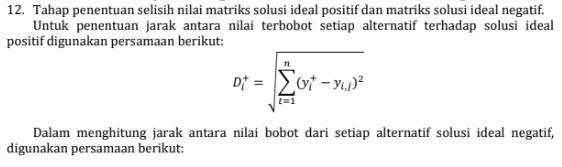

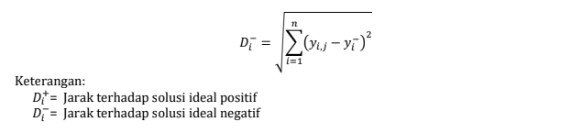

In [ ]:
import numpy as np

# Hitung jarak ke solusi ideal
D_pos = np.sqrt(((weighted_matrix - ideal_pos) ** 2).sum(axis=1))
D_neg = np.sqrt(((weighted_matrix - ideal_neg) ** 2).sum(axis=1))

Mencari Nilai Preferensi

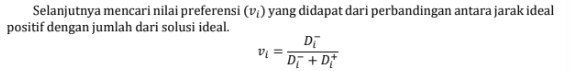

In [ ]:
# Hitung skor preferensi
preference_score = D_neg / (D_pos + D_neg)

# Hasil TOPSIS

In [ ]:
import numpy as np

# Hasil
hasil_topsis = pd.DataFrame({
    'Preference_Score': preference_score,
    'Rank': preference_score.rank(ascending=False).astype(int)
}, index=defuzzified_df.index).sort_values('Rank')

print(hasil_topsis.head(20))

       Preference_Score  Rank
31192          0.787763     1
42504          0.782221     2
56263          0.779915     3
4865           0.775313     4
38269          0.775275     5
52310          0.773199     6
31888          0.772590     7
55003          0.770679     8
46414          0.768664     9
21185          0.768106    10
47871          0.768080    12
71428          0.768080    12
38560          0.768080    12
72210          0.767068    14
79687          0.761969    15
79481          0.760093    16
7026           0.760068    17
25092          0.759155    18
36019          0.756693    19
13110          0.755734    20


In [ ]:
print(hasil_topsis.tail(20))

       Preference_Score   Rank
21311          0.072985  79838
30212          0.072985  79838
44896          0.072985  79838
42379          0.072985  79838
58180          0.072985  79838
49426          0.072985  79838
30915          0.072985  79838
20925          0.072985  79838
79161          0.072985  79838
12764          0.072985  79838
5397           0.072985  79838
11211          0.072985  79838
18285          0.072985  79838
17336          0.072985  79838
20241          0.072985  79838
49506          0.072985  79838
18864          0.072985  79838
57690          0.072985  79838
66802          0.072985  79838
75486          0.069057  79853
